# Step 3 – Modeling

## Business question

> **How should car brands optimize the characteristics of their cars to reduce CO2 and NOx – weighted by their registrations?**

### In plain words
A car maker cannot lower emissions "for free": heavier cars, bigger engines and more power usually mean more CO2, and diesel cars emit little CO2 but a lot of NOx. The question is therefore:

1. Can we **predict** CO2 and NOx (both in g/km) from a car's technical characteristics (power, weight, engine size, dimensions, fuel type, transmission, segment, body type, hybrid)?
2. If yes: which **combination of characteristics** gives the lowest emissions for a realistic car in each segment?
3. And how far away is each **brand** from that optimum today?

### Why "weighted by registrations"?
Every row is one vehicle configuration, and `r_merged` tells us how many real cars of that configuration were registered. A configuration sold 50,000 times must count more than one sold 3 times – otherwise a niche car would be as important as a best-seller. So `r_merged` is used as a **weight** everywhere: when training the models, in every metric (weighted R², RMSE, MAE), for the segment statistics and when aggregating per brand.

### Why two targets at once?
CO2 and NOx often pull in opposite directions (typically petrol vs. diesel), so there is usually **no single best car**, only a trade-off. We describe it with a **Pareto front**: a configuration is Pareto-optimal if no other configuration is at least as good on *both* CO2 and NOx and strictly better on one of them.

### How this notebook answers the question

| Question | Steps |
|---|---|
| Can we predict CO2 / NOx reliably? | 1–8: clean data, group-aware train/test split, baseline, tune 4 models with cross-validation, compare on the test set, check overfitting |
| What drives the emissions? | 9, 9b: feature importance and SHAP |
| What would emissions be for cars that do not exist yet? | 10–11: predictions for made-up specifications, global Pareto front |
| What is a *realistic* optimum per segment? | 11b: segment-specific Pareto fronts |
| How far is each brand from that optimum? | 11c: brand gap analysis |
| Where does the model go wrong? | 12: residuals; 13: save the models |

### Design decisions that matter
* **Grouped split:** near-identical "sibling" configurations always end up on the same side (train *or* test), otherwise the test score would be too optimistic.
* **Honest model selection:** hyperparameters and the best model per target are chosen by cross-validation on the training set only; the test set is used once at the end.
* **Baseline first:** a model that always predicts the weighted mean has R² ≈ 0 – every real model has to beat that.

### How to read the results
* The "optimal" configurations are the best points **our model** can find under the given constraints. They are not a business recommendation, because cost, feasibility and brand image are not modeled.
* Read every predicted optimum with the model's test error (weighted RMSE) in mind.
* The model finds statistical relationships, not causal effects.

In [1]:
import warnings
from itertools import product
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

# harmless: rare fuel/segment combinations have < 5 members, which StratifiedGroupKFold warns about
warnings.filterwarnings("ignore", message="The least populated class")

NUMERIC_FEATURES = ['power_max_kw', 'kerb_weight_min_kg', 'ec (cm3)', 'w (mm)', 'at1 (mm)', 'at2 (mm)']
CATEGORICAL_FEATURES = ['fuel_grp', 'transmission', 'segment_grp', 'body_type_grp', 'hybrid']
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGETS = ['co2_g_km', 'nox_g_km']
WEIGHT = 'r_merged'                       # real registrations = sample weight
TARGET_LABEL = {'co2_g_km': 'CO2', 'nox_g_km': 'NOx'}

## Step 1b – Load the data

In [2]:
candidates = [
    Path.cwd() / "df_model.csv",
    Path.cwd() / "co2" / "df_model.csv",
    Path("/Users/philipp/co2/df_model.csv"),
]
df_path = next((p for p in candidates if p.exists()), None)
if df_path is None:
    raise FileNotFoundError("df_model.csv wurde nicht gefunden.")

df_model = pd.read_csv(df_path)
print("Datei:", df_path)
print(f"df_model: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns")
if "_merge" in df_model.columns:
    print(df_model["_merge"].value_counts())

Datei: /Users/philipp/co2/df_model.csv
df_model: 3,660 rows x 54 columns
_merge
both    3660
Name: count, dtype: int64


## Step 2 – Build the modeling table and clean it

In [3]:
model_df = df_model[FEATURES + TARGETS + [WEIGHT]].copy()

missing_target = model_df[TARGETS].isna().any(axis=1)
bad_weight = model_df[WEIGHT].isna() | (model_df[WEIGHT] <= 0)
dropped = missing_target | bad_weight

print('=== Why rows get dropped in this cleaning step ===')
print(f'Rows total:                         {len(model_df):,}')
print(f'  - missing co2_g_km or nox_g_km:   {missing_target.sum():,}')
print(f'  - missing/zero/negative r_merged: {bad_weight.sum():,}')
print(f'  - dropped by either reason:       {dropped.sum():,}')
if '_merge' in df_model.columns:
    print('\n_merge status of the dropped rows (should now be almost entirely')
    print('target/weight issues, not merge-coverage issues):')
    print(df_model.loc[dropped, '_merge'].value_counts())

print(f'\nRows before target/weight cleaning: {len(model_df):,} -> after: {(~dropped).sum():,}')
model_df = model_df[~dropped]

print('\nMissing values per feature (these are NOT dropped here — they are')
print('handled later by imputation inside the pipeline, see Step 4):')
print(model_df[FEATURES].isna().sum())

=== Why rows get dropped in this cleaning step ===
Rows total:                         3,660
  - missing co2_g_km or nox_g_km:   25
  - missing/zero/negative r_merged: 0
  - dropped by either reason:       25

_merge status of the dropped rows (should now be almost entirely
target/weight issues, not merge-coverage issues):
_merge
both    25
Name: count, dtype: int64

Rows before target/weight cleaning: 3,660 -> after: 3,635

Missing values per feature (these are NOT dropped here — they are
handled later by imputation inside the pipeline, see Step 4):
power_max_kw            0
kerb_weight_min_kg      0
ec (cm3)                0
w (mm)                  0
at1 (mm)                0
at2 (mm)              325
fuel_grp                0
transmission            0
segment_grp             0
body_type_grp           0
hybrid                  0
dtype: int64


## Step 3 – Train/test split (grouped + stratified)

In [4]:
# Cars with (almost) identical specs are "siblings". We round the numeric specs and hash them together with
# the categorical ones, so siblings share one group id and can never be split between train and test.
ROUND_TO = {'power_max_kw': 5, 'kerb_weight_min_kg': 50, 'ec (cm3)': 100, 'w (mm)': 10, 'at1 (mm)': 10, 'at2 (mm)': 10}

def config_fingerprint(X, tolerance=1.0):
    rounded = pd.DataFrame({c: (X[c] / (step * tolerance)).round() * (step * tolerance) for c, step in ROUND_TO.items()})
    return pd.util.hash_pandas_object(pd.concat([rounded, X[CATEGORICAL_FEATURES]], axis=1), index=False)

model_df['config_group_id'] = config_fingerprint(model_df)

print('Sensitivity of the sibling grouping to the rounding tolerance:')
for label, tolerance in [('2x coarser tolerance:', 2), ('current tolerance:', 1), ('2x finer tolerance:', 0.5)]:
    print(f'  {label:<22}{config_fingerprint(model_df, tolerance).nunique():,} groups')
print('(close numbers => the grouping is reasonably robust to the exact tolerance)\n')

X, y, w = model_df[FEATURES], model_df[TARGETS], model_df[WEIGHT]
groups = model_df['config_group_id']
strat_label = X['fuel_grp'].astype(str) + '_' + X['segment_grp'].astype(str)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, strat_label, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
w_train, w_test = w.iloc[train_idx], w.iloc[test_idx]
groups_train, strat_label_train = groups.iloc[train_idx], strat_label.iloc[train_idx]

print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')
print(f'Weighted training volume: {w_train.sum():,.0f} | Weighted test volume: {w_test.sum():,.0f}')

def share_table(column):
    return pd.concat([X_train[column].value_counts(normalize=True).rename('train_share'),
                      X_test[column].value_counts(normalize=True).rename('test_share')], axis=1).round(4)

print('\nFuel type share, train vs. test:')
print(share_table('fuel_grp'))
print('\nSegment share, train vs. test (NEW - not checked in the previous version):')
print(share_table('segment_grp'))

sibling_share = groups.iloc[test_idx].isin(set(groups_train)).mean()
print(f'\nShare of test rows with a sibling group also present in train (should be ~0% by construction now): {sibling_share:.1%}')
print("Compare this to the old, ungrouped random split's sibling_share to see the fix's effect.")

Sensitivity of the sibling grouping to the rounding tolerance:
  2x coarser tolerance: 2,523 groups
  current tolerance:    2,789 groups
  2x finer tolerance:   2,888 groups
(close numbers => the grouping is reasonably robust to the exact tolerance)

Train: 2,908 rows | Test: 727 rows
Weighted training volume: 1,207,712 | Weighted test volume: 326,458

Fuel type share, train vs. test:
                 train_share  test_share
fuel_grp                                
Diesel                0.5805      0.5818
Petrol                0.3910      0.3934
Electric/Hybrid       0.0162      0.0138
Gas(-Mix)             0.0107      0.0110
E85                   0.0017         NaN

Segment share, train vs. test (NEW - not checked in the previous version):
              train_share  test_share
segment_grp                          
Lower-Medium       0.2662      0.2669
Low/Economy        0.2153      0.2160
Luxury             0.2132      0.2146
Upper-Medium       0.1764      0.1761
Premium            0.

## Step 4 – Preprocessing

In [5]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), NUMERIC_FEATURES),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL_FEATURES),
])

def make_pipe(estimator, wrap=False):
    """Preprocessing + model. wrap=True fits one copy of the model per target (for models that only handle one target)."""
    return Pipeline([('prep', preprocessor), ('model', MultiOutputRegressor(estimator) if wrap else estimator)])

# The CV folds are identical for every model, so we build them once (training set only).
CV_FOLDS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
                .split(X_train, strat_label_train, groups=groups_train))

def cv_r2(build_pipe, params=None):
    """Weighted R2 per target, averaged over the grouped + stratified CV folds."""
    scores = {t: [] for t in TARGETS}
    for tr, val in CV_FOLDS:
        pipe = build_pipe(params)
        pipe.fit(X_train.iloc[tr], y_train.iloc[tr], model__sample_weight=w_train.iloc[tr])
        pred = pipe.predict(X_train.iloc[val])
        for i, t in enumerate(TARGETS):
            scores[t].append(r2_score(y_train.iloc[val, i], pred[:, i], sample_weight=w_train.iloc[val]))
    return {t: float(np.mean(s)) for t, s in scores.items()}

## Step 4b – Baseline (weighted mean)

In [6]:
def build_baseline(params=None):
    return make_pipe(DummyRegressor(strategy='mean'), wrap=True)

baseline_cv_per_target = cv_r2(build_baseline)
print('Baseline (weighted mean) - weighted CV R2 per target:')
for t, score in baseline_cv_per_target.items():
    print(f'  {t}: {round(score, 4)}')

baseline_final = build_baseline().fit(X_train, y_train, model__sample_weight=w_train)
print('\nBaseline fitted on the full training set - will be included in the Step 6 comparison table.')

Baseline (weighted mean) - weighted CV R2 per target:
  co2_g_km: -0.0404
  nox_g_km: -0.0258

Baseline fitted on the full training set - will be included in the Step 6 comparison table.


## Step 5 – Tune the four models (weighted, grouped + stratified CV)

The best hyperparameters per model are chosen by cross-validation on the **training set only**; the test set is not touched here.

In [7]:
MODEL_SPECS = {
    'Ridge': dict(
        estimator=Ridge, fixed={}, wrap=True,
        grid={'alpha': [0.1, 1.0, 10.0, 100.0]}),
    'Gradient Boosting': dict(
        estimator=GradientBoostingRegressor, fixed={'random_state': 42}, wrap=True,
        grid={'n_estimators': [100, 200], 'max_depth': [2, 3]}),
    'Random Forest': dict(
        estimator=RandomForestRegressor, fixed={'random_state': 42, 'n_jobs': -1}, wrap=False,
        grid={'n_estimators': [100, 200], 'max_depth': [10, 15, None], 'max_features': ['sqrt', 0.8], 'min_samples_leaf': [1, 3]}),
    'XGBoost': dict(
        estimator=XGBRegressor, fixed={'random_state': 42, 'n_jobs': -1}, wrap=False,
        grid={'n_estimators': [200, 300], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1],
              'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]}),
}

models = {'Baseline (mean)': baseline_final}
cv_scores_per_target = {'Baseline (mean)': baseline_cv_per_target}
search_results = {}

for name, spec in MODEL_SPECS.items():
    print(f'=== {name}: weighted K-Fold search ===')

    def build(params, spec=spec):
        return make_pipe(spec['estimator'](**spec['fixed'], **params), spec['wrap'])

    rows = []
    for values in product(*spec['grid'].values()):
        params = dict(zip(spec['grid'], values))
        scores = cv_r2(build, params)
        rows.append({**params, 'weighted_R2_cv': float(np.mean(list(scores.values()))),
                     **{f'weighted_R2_cv__{t}': s for t, s in scores.items()}})

    best = max(rows, key=lambda r: r['weighted_R2_cv'])
    best_params = {k: best[k] for k in spec['grid']}
    best_per_target = {t: best[f'weighted_R2_cv__{t}'] for t in TARGETS}
    print(f'Best {name} parameters (weighted CV):', best_params)
    print('Best weighted CV R2 (combined):', round(best['weighted_R2_cv'], 4))
    print('Best weighted CV R2 (per target):', {k: round(v, 4) for k, v in best_per_target.items()})

    models[name] = build(best_params).fit(X_train, y_train, model__sample_weight=w_train)
    cv_scores_per_target[name] = best_per_target
    search_results[name] = pd.DataFrame(rows).sort_values('weighted_R2_cv', ascending=False)
    print()

=== Ridge: weighted K-Fold search ===
Best Ridge parameters (weighted CV): {'alpha': 10.0}
Best weighted CV R2 (combined): 0.8169
Best weighted CV R2 (per target): {'co2_g_km': 0.7644, 'nox_g_km': 0.8695}

=== Gradient Boosting: weighted K-Fold search ===
Best Gradient Boosting parameters (weighted CV): {'n_estimators': 200, 'max_depth': 3}
Best weighted CV R2 (combined): 0.8794
Best weighted CV R2 (per target): {'co2_g_km': 0.8517, 'nox_g_km': 0.907}

=== Random Forest: weighted K-Fold search ===
Best Random Forest parameters (weighted CV): {'n_estimators': 100, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1}
Best weighted CV R2 (combined): 0.8631
Best weighted CV R2 (per target): {'co2_g_km': 0.8271, 'nox_g_km': 0.8992}

=== XGBoost: weighted K-Fold search ===
Best XGBoost parameters (weighted CV): {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best weighted CV R2 (combined): 0.8926
Best weighted CV R2 (per targe

## Step 6 – Compare the models and pick the best one per target

In [8]:
results = []
for name, model in models.items():
    pred = model.predict(X_test)
    for i, t in enumerate(TARGETS):
        y_true = y_test.iloc[:, i]
        results.append({
            'model': name, 'target': t,
            'weighted_RMSE': np.sqrt(mean_squared_error(y_true, pred[:, i], sample_weight=w_test)),
            'weighted_MAE': mean_absolute_error(y_true, pred[:, i], sample_weight=w_test),
            'weighted_R2': r2_score(y_true, pred[:, i], sample_weight=w_test),
            'weighted_R2_cv': cv_scores_per_target[name][t],
        })
comparison_df = pd.DataFrame(results)
test_metrics = comparison_df.set_index(['model', 'target'])

print('\n=== Comparing all models, incl. baseline, on the test set (weighted) ===')
print(comparison_df.round(4))

print('\n=== Model selection (based on weighted CV R2) vs. test-set cross-check ===')
best_name, best_model = {}, {}
for t in TARGETS:
    candidates_t = comparison_df[(comparison_df['target'] == t) & (comparison_df['model'] != 'Baseline (mean)')]
    cv_best = candidates_t.loc[candidates_t['weighted_R2_cv'].idxmax(), 'model']
    test_best = candidates_t.loc[candidates_t['weighted_R2'].idxmax(), 'model']
    agreement = ('same model -> more confidence in this choice' if cv_best == test_best
                 else 'DIFFERENT - CV choice is still used, but flag this as a limitation in the report')
    print(f'{t}: CV-best (selection criterion) = {cv_best}, Test-best (reference only) = {test_best} -> {agreement}')
    best_name[t], best_model[t] = cv_best, models[cv_best]

print(f"\nBest model for CO2 (selected via CV): {best_name['co2_g_km']}")
print(f"Best model for NOx (selected via CV): {best_name['nox_g_km']}")

def test_r2(model_name, target):
    return test_metrics.loc[(model_name, target), 'weighted_R2']

print(f"\nBaseline test R2 -> CO2: {test_r2('Baseline (mean)', 'co2_g_km'):.4f} | NOx: {test_r2('Baseline (mean)', 'nox_g_km'):.4f}")
print(f"Chosen model test R2 -> CO2: {test_r2(best_name['co2_g_km'], 'co2_g_km'):.4f} ({best_name['co2_g_km']}) "
      f"| NOx: {test_r2(best_name['nox_g_km'], 'nox_g_km'):.4f} ({best_name['nox_g_km']})")
print('This comparison shows how much the chosen models improve over simply predicting the (weighted) average - the key number to justify using a real model at all.')

def predict(target, X_new):
    """Prediction of the best model for one target."""
    return best_model[target].predict(X_new)[:, TARGETS.index(target)]


=== Comparing all models, incl. baseline, on the test set (weighted) ===
               model    target  weighted_RMSE  weighted_MAE  weighted_R2  \
0    Baseline (mean)  co2_g_km        20.4689       15.2165      -0.0470   
1    Baseline (mean)  nox_g_km         0.0655        0.0595      -0.0797   
2              Ridge  co2_g_km         9.1515        7.2157       0.7907   
3              Ridge  nox_g_km         0.0192        0.0131       0.9073   
4  Gradient Boosting  co2_g_km         8.9238        6.8698       0.8010   
5  Gradient Boosting  nox_g_km         0.0152        0.0114       0.9419   
6      Random Forest  co2_g_km         9.9040        6.9721       0.7549   
7      Random Forest  nox_g_km         0.0174        0.0125       0.9237   
8            XGBoost  co2_g_km         9.7525        6.7735       0.7623   
9            XGBoost  nox_g_km         0.0151        0.0105       0.9427   

   weighted_R2_cv  
0         -0.0404  
1         -0.0258  
2          0.7644  
3        

## Step 7 – Bar charts: R² and MAE per model

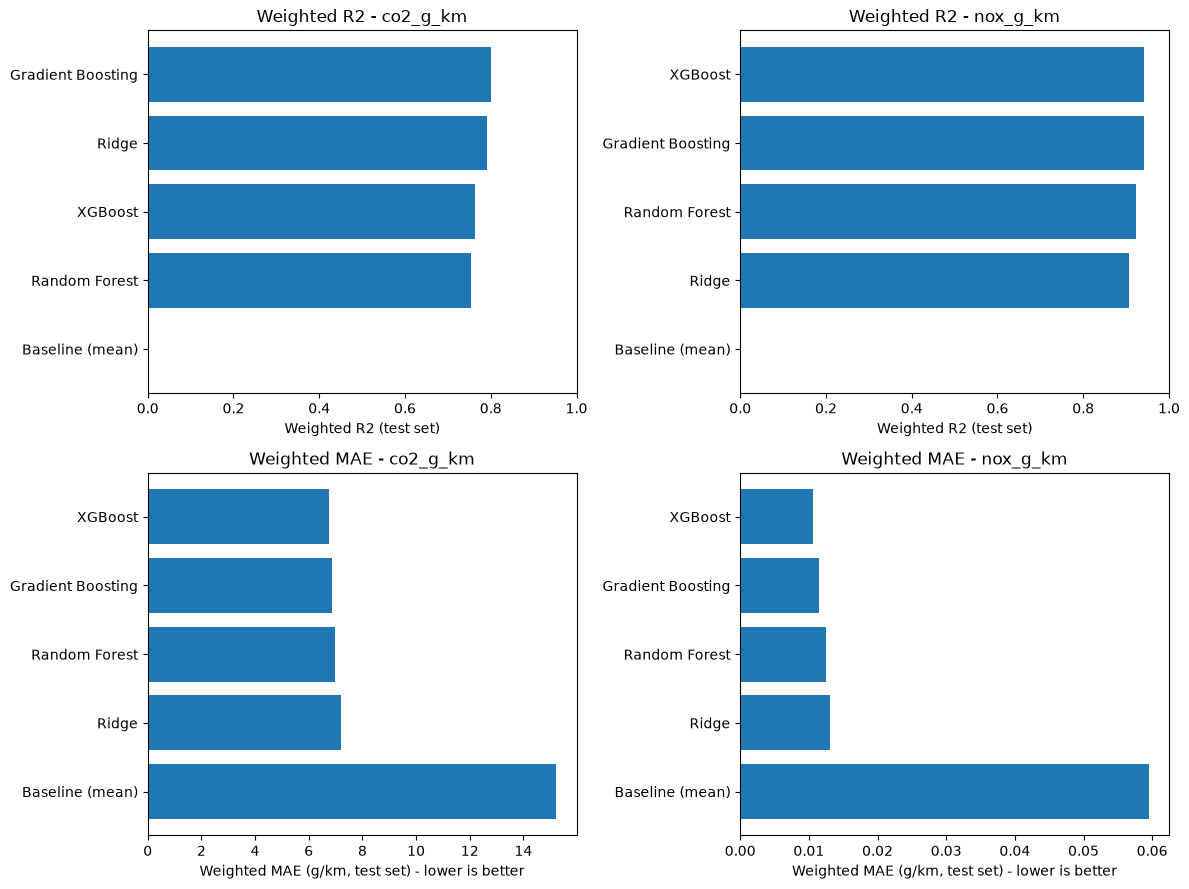

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for col, t in enumerate(TARGETS):
    subset = comparison_df[comparison_df['target'] == t]

    by_r2 = subset.sort_values('weighted_R2')
    axes[0, col].barh(by_r2['model'], by_r2['weighted_R2'])
    axes[0, col].set_xlim(0, 1)
    axes[0, col].set_title(f'Weighted R2 - {t}')
    axes[0, col].set_xlabel('Weighted R2 (test set)')

    by_mae = subset.sort_values('weighted_MAE', ascending=False)
    axes[1, col].barh(by_mae['model'], by_mae['weighted_MAE'])
    axes[1, col].set_title(f'Weighted MAE - {t}')
    axes[1, col].set_xlabel('Weighted MAE (g/km, test set) - lower is better')
plt.tight_layout()
plt.show()

## Step 8 – Overfitting check (train vs. CV vs. test)

In [10]:
rows = []
for name, model in models.items():
    pred_train = model.predict(X_train)
    for i, t in enumerate(TARGETS):
        r2_train = r2_score(y_train.iloc[:, i], pred_train[:, i], sample_weight=w_train)
        r2_cv, r2_test = cv_scores_per_target[name][t], test_r2(name, t)
        rows.append({'model': name, 'target': t, 'weighted_R2_train': r2_train, 'weighted_R2_cv': r2_cv,
                     'weighted_R2_test': r2_test, 'gap_train_cv': r2_train - r2_cv, 'gap_cv_test': r2_cv - r2_test})
overfit_df = pd.DataFrame(rows)

print('\n=== Train vs. CV vs. test weighted R2 ===')
print('A big train->CV gap means the model overfits during tuning itself.')
print('A big CV->test gap means even the CV estimate was too optimistic.')
print(overfit_df.round(4).sort_values('gap_train_cv', ascending=False))


=== Train vs. CV vs. test weighted R2 ===
A big train->CV gap means the model overfits during tuning itself.
A big CV->test gap means even the CV estimate was too optimistic.
               model    target  weighted_R2_train  weighted_R2_cv  \
6      Random Forest  co2_g_km             0.9667          0.8271   
8            XGBoost  co2_g_km             0.9887          0.8778   
4  Gradient Boosting  co2_g_km             0.9545          0.8517   
9            XGBoost  nox_g_km             0.9963          0.9073   
7      Random Forest  nox_g_km             0.9865          0.8992   
5  Gradient Boosting  nox_g_km             0.9757          0.9070   
2              Ridge  co2_g_km             0.8096          0.7644   
0    Baseline (mean)  co2_g_km             0.0000         -0.0404   
3              Ridge  nox_g_km             0.8964          0.8695   
1    Baseline (mean)  nox_g_km             0.0000         -0.0258   

   weighted_R2_test  gap_train_cv  gap_cv_test  
6            0.

## Step 9 – Feature importance

In [11]:
def get_importance(target):
    """('tree' | 'ridge' | None, Series) for the best model of one target."""
    pipe = best_model[target]
    step, names = pipe.named_steps['model'], pipe.named_steps['prep'].get_feature_names_out()
    if hasattr(step, 'feature_importances_'):
        return 'tree', pd.Series(step.feature_importances_, index=names)
    if hasattr(step, 'estimators_') and hasattr(step.estimators_[TARGETS.index(target)], 'coef_'):
        return 'ridge', pd.Series(step.estimators_[TARGETS.index(target)].coef_, index=names)
    return None, None

same_model = best_name['co2_g_km'] == best_name['nox_g_km']
if same_model:
    print(f"NOTE: {best_name['co2_g_km']} was selected for BOTH targets. For this model type, feature_importances_ is one shared array, so the CO2 and NOx rankings below will be IDENTICAL, not just similar. Use SHAP (Step 9b) for a per-target breakdown instead.")

importance = {}
for t in TARGETS:
    kind, imp = get_importance(t)
    importance[t] = (kind, imp)
    label = TARGET_LABEL[t]
    if kind == 'tree':
        print(f'\n=== Feature importance for {label} (tree-based model, raw values after one-hot encoding) ===')
        print(imp.sort_values(ascending=False).round(4))
    elif kind == 'ridge':
        print(f'\n=== Ridge coefficients for {label} (standardized scale, after one-hot encoding) ===')
        print('Positive = pushes the prediction up, negative = pushes it down.')
        print(imp.sort_values(key=abs, ascending=False).round(4))
    else:
        print(f'\n=== Feature importance for {label} skipped (the best model here does not expose feature_importances_ or coef_) ===')

target_corr = y_train['co2_g_km'].corr(y_train['nox_g_km'])
print(f'\nCorrelation between actual co2_g_km and nox_g_km (training set): {target_corr:.3f}')

imp_co2, imp_nox = (importance[t][1] for t in TARGETS)
if same_model:
    print('\n(Side-by-side comparison skipped: same model for both targets, so the')
    print('two importance columns would just be identical - see NOTE above instead.)')
elif imp_co2 is not None and imp_nox is not None:
    side_by_side = pd.DataFrame({'CO2_importance': imp_co2.abs(), 'NOx_importance': imp_nox.abs()}
                                ).sort_values('CO2_importance', ascending=False)
    rank_corr = side_by_side['CO2_importance'].rank().corr(side_by_side['NOx_importance'].rank())
    print('\n=== CO2 vs. NOx importance, side by side (sorted by CO2 importance) ===')
    print(side_by_side.round(4))
    print(f'\nSpearman rank correlation between the two importance rankings: {rank_corr:.3f}')
else:
    print('\n(Side-by-side CO2 vs. NOx importance comparison skipped - one of the')
    print('two best models does not expose feature_importances_ or coef_.)')

NOTE: XGBoost was selected for BOTH targets. For this model type, feature_importances_ is one shared array, so the CO2 and NOx rankings below will be IDENTICAL, not just similar. Use SHAP (Step 9b) for a per-target breakdown instead.

=== Feature importance for CO2 (tree-based model, raw values after one-hot encoding) ===
cat__fuel_grp_Petrol                    0.2586
cat__hybrid_oui                         0.1179
cat__body_type_grp_Sedan / Hatchback    0.0932
cat__fuel_grp_Electric/Hybrid           0.0713
cat__body_type_grp_SUV / Off-road       0.0536
num__ec (cm3)                           0.0534
cat__hybrid_non                         0.0440
cat__fuel_grp_Gas(-Mix)                 0.0321
cat__body_type_grp_Station Wagon        0.0306
cat__fuel_grp_Diesel                    0.0297
num__kerb_weight_min_kg                 0.0296
num__power_max_kw                       0.0228
cat__segment_grp_Lower-Medium           0.0181
cat__segment_grp_Low/Economy            0.0175
cat__transmission_

**How to read this:** if the two targets were strongly correlated, their importance rankings would look alike simply because both are driven by overlapping physical causes (mostly fuel type). Check the correlation printed above before interpreting a similar ranking. SHAP (Step 9b) gives the clearer, per-target and per-car view.

## Step 9b – SHAP


=== SHAP - mean |impact| per feature, CO2 (g/km, sample of 300 test rows) ===
cat__fuel_grp_Petrol                    13.551
num__kerb_weight_min_kg                 12.839
num__ec (cm3)                           10.625
cat__fuel_grp_Gas(-Mix)                  8.159
cat__transmission_A 6                    6.446
num__power_max_kw                        6.412
cat__transmission_A 4                    6.104
cat__fuel_grp_Electric/Hybrid            5.225
cat__transmission_D 7                    4.830
cat__hybrid_oui                          4.235
num__w (mm)                              2.424
cat__body_type_grp_Sedan / Hatchback     1.967
num__at2 (mm)                            1.843
num__at1 (mm)                            1.815
cat__segment_grp_Luxury                  1.770
dtype: float32


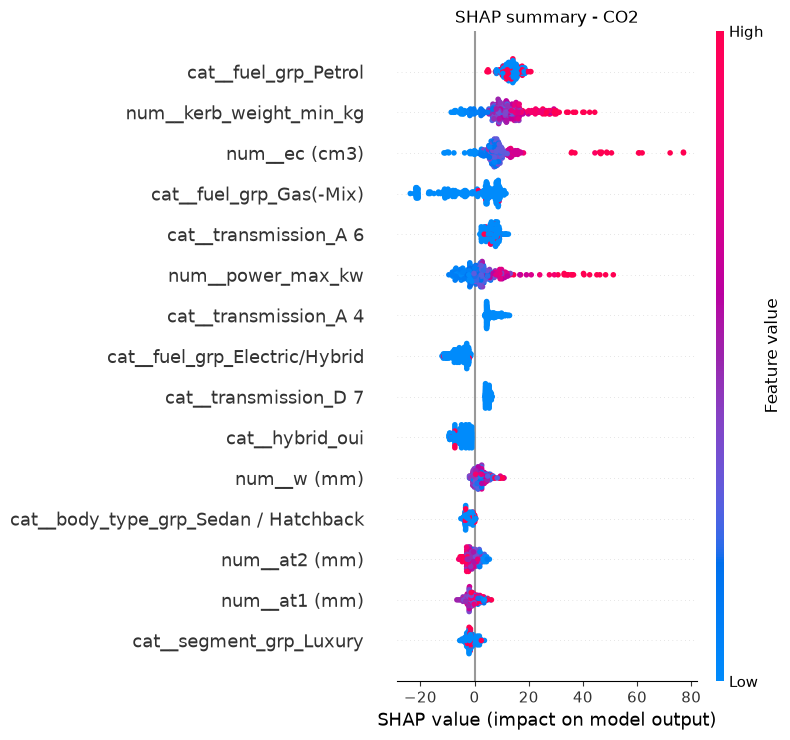


=== SHAP - mean |impact| per feature, NOx (g/km, sample of 300 test rows) ===
cat__fuel_grp_Diesel          0.033
cat__body_type_grp_Minibus    0.016
num__kerb_weight_min_kg       0.012
num__at1 (mm)                 0.009
cat__fuel_grp_Petrol          0.008
num__power_max_kw             0.007
cat__transmission_A 5         0.006
num__w (mm)                   0.005
num__ec (cm3)                 0.004
cat__transmission_S 6         0.004
cat__transmission_A 7         0.003
num__at2 (mm)                 0.003
cat__segment_grp_Luxury       0.003
cat__transmission_V 0         0.003
cat__transmission_A 8         0.003
dtype: float32


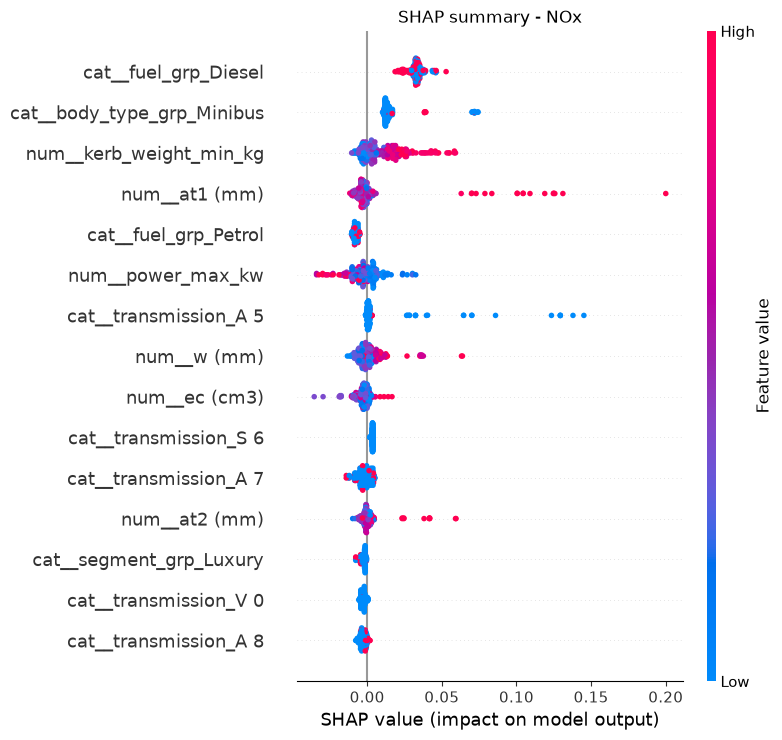

In [12]:
try:
    import shap
except ImportError:
    shap = None

SHAP_SAMPLE_SIZE = 300

def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, 'toarray') else matrix

def explain_with_shap(target, X_explain):
    pipe = best_model[target]
    step, prep = pipe.named_steps['model'], pipe.named_steps['prep']
    names, ti = prep.get_feature_names_out(), TARGETS.index(target)
    X_ex = to_dense(prep.transform(X_explain))

    if hasattr(step, 'feature_importances_'):        # Random Forest / XGBoost: one model for both targets
        raw = shap.TreeExplainer(step).shap_values(X_ex)
        sv = raw[ti] if isinstance(raw, list) else raw[:, :, ti]
    else:                                            # MultiOutputRegressor: one model per target
        inner = step.estimators_[ti]
        explainer = (shap.LinearExplainer(inner, to_dense(prep.transform(X_train))) if hasattr(inner, 'coef_')
                     else shap.TreeExplainer(inner))
        sv = explainer.shap_values(X_ex)

    print(f'\n=== SHAP - mean |impact| per feature, {TARGET_LABEL[target]} (g/km, sample of {len(X_ex)} test rows) ===')
    print(pd.Series(np.abs(sv).mean(axis=0), index=names).sort_values(ascending=False).round(3).head(15))
    shap.summary_plot(sv, X_ex, feature_names=names, show=False, max_display=15)
    plt.title(f'SHAP summary - {TARGET_LABEL[target]}')
    plt.tight_layout()
    plt.show()

if shap is None:
    print('SHAP is not installed. Step 9b is skipped.')
else:
    X_shap_sample = X_test.sample(n=min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=42)
    for t in TARGETS:
        explain_with_shap(t, X_shap_sample)

**How to read the summary plots:** each dot is one car. Its position on the x-axis is that feature's contribution to the prediction for that car (in g/km); the color is the feature's own value (red = high, blue = low). A cluster of red dots on the positive side for weight means "heavy cars get a positive CO2 push, and the heavier the car, the bigger that push" – a directional, per-car statement that the plain importance ranking of Step 9 cannot make, and one that informs the brand-level results in Step 11c.

## Step 10 – Predict emissions for made-up car specifications

In [13]:
quantile_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
weight_values, engine_values, power_values = (np.quantile(X_train[c], quantile_levels)
                                              for c in ['kerb_weight_min_kg', 'ec (cm3)', 'power_max_kw'])
median_dims = X_train[['w (mm)', 'at1 (mm)', 'at2 (mm)']].median().to_dict()                # everything else is held "typical"
typical_cats = {c: X_train[c].mode()[0] for c in ['transmission', 'segment_grp', 'body_type_grp', 'hybrid']}

grid_df = pd.DataFrame([
    {'kerb_weight_min_kg': wt, 'ec (cm3)': ec, 'power_max_kw': kw, **median_dims, 'fuel_grp': fuel, **typical_cats}
    for wt, ec, kw, fuel in product(weight_values, engine_values, power_values, X_train['fuel_grp'].unique())
])
print(f'\nNumber of made-up combinations: {len(grid_df)}')

grid_df['predict_co2'] = predict('co2_g_km', grid_df)
grid_df['predict_nox'] = predict('nox_g_km', grid_df).clip(min=0)

print('\nFirst rows of the table with predicted emissions:')
print(grid_df.head())


Number of made-up combinations: 625

First rows of the table with predicted emissions:
   kerb_weight_min_kg  ec (cm3)  power_max_kw  w (mm)  at1 (mm)  at2 (mm)  \
0              1165.0    1329.0          66.0  2708.0    1551.0    1552.0   
1              1165.0    1329.0          66.0  2708.0    1551.0    1552.0   
2              1165.0    1329.0          66.0  2708.0    1551.0    1552.0   
3              1165.0    1329.0          66.0  2708.0    1551.0    1552.0   
4              1165.0    1329.0          66.0  2708.0    1551.0    1552.0   

          fuel_grp transmission   segment_grp      body_type_grp hybrid  \
0           Petrol          M 6  Lower-Medium  Sedan / Hatchback    non   
1           Diesel          M 6  Lower-Medium  Sedan / Hatchback    non   
2  Electric/Hybrid          M 6  Lower-Medium  Sedan / Hatchback    non   
3              E85          M 6  Lower-Medium  Sedan / Hatchback    non   
4        Gas(-Mix)          M 6  Lower-Medium  Sedan / Hatchback    non   

## Step 11 – Exploratory global Pareto front

In [14]:
def find_pareto_optimal(values):
    """True for every row that no other row beats on both columns (lower is better) - and is strictly better on one."""
    v = np.asarray(values)
    at_least_as_good = (v[:, None, :] <= v[None, :, :]).all(axis=2)     # [j, i]: row j is no worse than row i
    strictly_better = (v[:, None, :] < v[None, :, :]).any(axis=2)       # [j, i]: row j is better on at least one
    return ~(at_least_as_good & strictly_better).any(axis=0)

grid_df['pareto_optimal'] = find_pareto_optimal(grid_df[['predict_co2', 'predict_nox']].values)
pareto_df = grid_df[grid_df['pareto_optimal']].sort_values('predict_co2').reset_index(drop=True)

print(f'\nPareto-optimal combinations: {len(pareto_df)} out of {len(grid_df)}')
print(pareto_df[['fuel_grp', 'kerb_weight_min_kg', 'ec (cm3)', 'power_max_kw', 'predict_co2', 'predict_nox']].round(2))


Pareto-optimal combinations: 9 out of 625
          fuel_grp  kerb_weight_min_kg  ec (cm3)  power_max_kw  predict_co2  \
0  Electric/Hybrid              1165.0    1329.0         110.0    97.629997   
1              E85              1165.0    1329.0          85.0   105.629997   
2              E85              1165.0    1329.0         110.0   107.559998   
3        Gas(-Mix)              1165.0    2995.0         110.0   115.760002   
4        Gas(-Mix)              1165.0    1329.0         110.0   119.599998   
5        Gas(-Mix)              1165.0    2143.0         110.0   128.000000   
6        Gas(-Mix)              1165.0    2143.0          85.0   130.699997   
7        Gas(-Mix)              1165.0    1598.0         110.0   131.940002   
8           Petrol              1165.0    1598.0         110.0   140.649994   

   predict_nox  
0         0.03  
1         0.02  
2         0.02  
3         0.02  
4         0.01  
5         0.01  
6         0.01  
7         0.01  
8         0.0

## Step 11b – Segment-specific, registration-weighted Pareto fronts

The global Pareto front mixes all segments, so its optimum (usually a light, small-engine petrol/hybrid) is not something an SUV or luxury brand can act on. Per segment we therefore:

1. take the **most-registered real cars** as *seeds* (this keeps realistic weight/engine/power combinations),
2. **vary weight, power and engine size** by ±7.5 % / ±15 % around each seed (new configurations the model has never seen),
3. **clip** every value to the registration-weighted 25th–95th percentile of the segment, so the search cannot drift to unrealistically light or weak cars,
4. predict CO2 and NOx and keep the **Pareto-optimal** points, and pick the lowest-CO2 point as the segment's optimum.

In [15]:
def weighted_percentile(values, weights, percentile):
    order = np.argsort(values)
    values, weights = np.asarray(values)[order], np.asarray(weights)[order]
    cum_weights = (np.cumsum(weights) - 0.5 * weights) / weights.sum()
    return np.interp(percentile / 100, cum_weights, values)

MIN_REG_SHARE = 0.01                                 # a seed car needs >= 1% of its segment's registrations
TOP_N_SEEDS = 8                                      # number of most-registered cars per segment used as seeds
PERTURBATIONS = [-0.15, -0.075, 0.0, 0.075, 0.15]    # relative changes applied to weight / power / engine size
CLIP_LOWER_PCT, CLIP_UPPER_PCT = 25, 95              # weighted percentile range that stays "realistic"

SEARCH_DIMS = {'kerb_weight_min_kg': 'd_weight', 'power_max_kw': 'd_power', 'ec (cm3)': 'd_engine'}
changes = pd.DataFrame(list(product(PERTURBATIONS, repeat=3)), columns=list(SEARCH_DIMS.values()))

base_df = df_model.dropna(subset=FEATURES + [WEIGHT, 'segment_grp'])
base_df = base_df[base_df[WEIGHT] > 0]

segment_pareto_frames, optimal_rows = [], []
for segment, seg_df in base_df.groupby('segment_grp', sort=False):
    seg_df = seg_df.assign(reg_share=seg_df[WEIGHT] / seg_df[WEIGHT].sum())
    bounds = {c: (weighted_percentile(seg_df[c], seg_df[WEIGHT], CLIP_LOWER_PCT),
                  weighted_percentile(seg_df[c], seg_df[WEIGHT], CLIP_UPPER_PCT)) for c in SEARCH_DIMS}
    typical = {c: np.average(seg_df[c], weights=seg_df[WEIGHT]) for c in SEARCH_DIMS}

    seeds = seg_df[seg_df['reg_share'] >= MIN_REG_SHARE].sort_values('reg_share', ascending=False)
    if seeds.empty:
        seeds = seg_df.sort_values(WEIGHT, ascending=False)
    seeds = seeds.head(TOP_N_SEEDS)

    combos = seeds[FEATURES].merge(changes, how='cross')                  # every seed x every combination of changes
    for column, change in SEARCH_DIMS.items():
        combos[column] = (combos[column] * (1 + combos[change])).clip(*bounds[column])
    combos = (combos.drop_duplicates(subset=[*SEARCH_DIMS, 'fuel_grp'])[FEATURES].reset_index(drop=True))

    combos['predict_co2'] = predict('co2_g_km', combos[FEATURES])
    combos['predict_nox'] = predict('nox_g_km', combos[FEATURES]).clip(min=0)
    seg_pareto = combos[find_pareto_optimal(combos[['predict_co2', 'predict_nox']].values)].copy()
    segment_pareto_frames.append(seg_pareto)

    best_row = seg_pareto.loc[seg_pareto['predict_co2'].idxmin()]          # lowest-CO2 point on the Pareto front
    optimal_rows.append({
        'segment': segment,
        'optimal_fuel': best_row['fuel_grp'],
        'optimal_weight_kg': round(best_row['kerb_weight_min_kg']),
        'optimal_engine_cm3': round(best_row['ec (cm3)']),
        'optimal_power_kw': round(best_row['power_max_kw']),
        'optimal_co2': round(best_row['predict_co2'], 1),
        'optimal_nox': round(best_row['predict_nox'], 3),
        'typical_weight_kg': round(typical['kerb_weight_min_kg']),
        'typical_power_kw': round(typical['power_max_kw']),
        'typical_engine_cm3': round(typical['ec (cm3)']),
        'n_pareto_options': len(seg_pareto),
    })

segment_pareto_df = pd.concat(segment_pareto_frames, ignore_index=True)
segment_optimal = pd.DataFrame(optimal_rows).sort_values('optimal_co2').reset_index(drop=True)

print(f"Segment-specific Pareto points: {len(segment_pareto_df)} across {segment_optimal['segment'].nunique()} segments\n")
print('=== One clear, realistic optimum per segment ===')
print(segment_optimal.to_string(index=False))

co2_rmse = test_metrics.loc[(best_name['co2_g_km'], 'co2_g_km'), 'weighted_RMSE']
print(f'\nModel uncertainty (weighted RMSE, test set): +/- {co2_rmse:.1f} g/km CO2')
print('Read every optimal CO2 value above with this margin in mind.')

Segment-specific Pareto points: 36 across 5 segments

=== One clear, realistic optimum per segment ===
     segment    optimal_fuel  optimal_weight_kg  optimal_engine_cm3  optimal_power_kw  optimal_co2  optimal_nox  typical_weight_kg  typical_power_kw  typical_engine_cm3  n_pareto_options
 Low/Economy          Diesel               1146                1461                71    84.900002        0.133               1146                64                1319                15
Lower-Medium          Diesel               1290                1560                81    92.000000        0.118               1404                86                1602                 8
Upper-Medium Electric/Hybrid               1707                2147               129    99.599998        0.072               1576               101                1840                 5
      Luxury          Diesel               1560                2143               110   121.000000        0.083               1795               152 

The three search dimensions are correlated (bigger engines come with more power and weight), which is why seeds are real cars instead of independent random draws:

In [16]:
df_model[['kerb_weight_min_kg', 'ec (cm3)', 'power_max_kw']].corr()

,kerb_weight_min_kg,ec (cm3),power_max_kw
kerb_weight_min_kg,1.000000,0.630162,0.548203
ec (cm3),0.630162,1.000000,0.924175
power_max_kw,0.548203,0.924175,1.000000


## Step 11c – Brand-level gap to the segment-specific optimum

For every real car we ask: *given its segment and its current NOx, how much lower could its CO2 be without making NOx worse?* (and the same the other way round). The answer is read off the car's own segment Pareto front. Cars without a comparable Pareto point are left out (`NaN`) instead of being scored as "already optimal". The gaps are then averaged per brand, weighted by registrations.

Brand column used: 'brand_group' (45 distinct brands)
Computing Pareto gap for 3,635 vehicle configurations (this can take a moment)...
Excluded from the ranking below (fewer than 50% of their cars had a comparable same-NOx-class Pareto point in their own segment - avg_co2_gap would not be reliable):
             comparable_share  n_cars
brand_clean                          
PORSCHE                  0.08    49.0
HONDA                    0.45    31.0
MAZDA                    0.44    43.0
LEXUS                    0.12    16.0
SMART                    0.17    18.0

=== Brands furthest from their segment-specific optimum (weighted by registrations) ===
                   registrations  avg_co2_gap  avg_nox_gap  comparable_share  \
brand_clean                                                                    
JEEP                      1248.0        85.26         0.08              0.67   
SSANGYONG                  234.0        67.23         0.11              1.00   
SUBARU                 

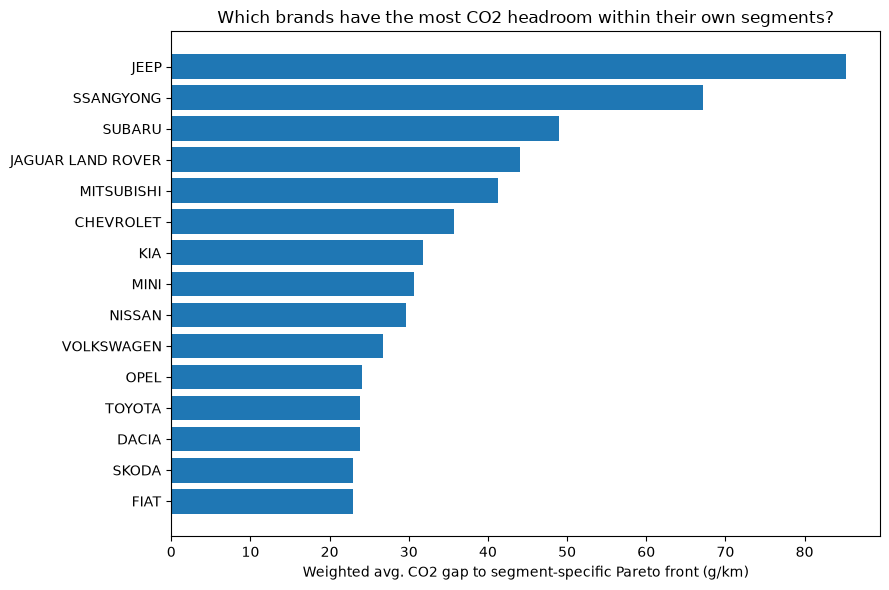

In [17]:
def gap_to_pareto(cars, actual_col, other_col, pareto_target, pareto_other):
    """Possible reduction of `actual_col` at least as good on `other_col`, using the car's own segment Pareto front.
    NaN if the segment has no Pareto point that is at least as good on `other_col`."""
    gaps = pd.Series(np.nan, index=cars.index)
    for segment, seg_cars in cars.groupby('segment_grp'):
        points = segment_pareto_df[segment_pareto_df['segment_grp'] == segment]
        if points.empty:
            continue
        comparable = points[pareto_other].values[None, :] <= seg_cars[other_col].values[:, None]      # cars x points
        best_possible = np.where(comparable, points[pareto_target].values[None, :], np.inf).min(axis=1)
        gaps[seg_cars.index] = np.where(np.isfinite(best_possible),
                                        np.maximum(seg_cars[actual_col] - best_possible, 0.0), np.nan)
    return gaps

# df_model.csv may not contain 'brand_clean' - use the first brand column that exists and clean it the same way
brand_source = next((c for c in ['brand_clean', 'brand', 'brand_group', 'brand_both'] if c in df_model.columns), None)
if brand_source is None:
    raise KeyError(f"No brand column found in df_model. Available columns: {list(df_model.columns)}")

brand_df = df_model[FEATURES + TARGETS + [WEIGHT]].assign(
    brand_clean=df_model[brand_source].astype('string').str.upper().str.strip())
brand_df = brand_df.dropna(subset=TARGETS + [WEIGHT, 'segment_grp', 'brand_clean'])
brand_df = brand_df[brand_df[WEIGHT] > 0].copy()
brand_df['brand_clean'] = brand_df['brand_clean'].astype(object)
print(f"Brand column used: '{brand_source}' ({brand_df['brand_clean'].nunique()} distinct brands)")

print(f'Computing Pareto gap for {len(brand_df):,} vehicle configurations (this can take a moment)...')
brand_df['co2_gap'] = gap_to_pareto(brand_df, 'co2_g_km', 'nox_g_km', 'predict_co2', 'predict_nox')
brand_df['nox_gap'] = gap_to_pareto(brand_df, 'nox_g_km', 'co2_g_km', 'predict_nox', 'predict_co2')

# registration-weighted average per brand, ignoring cars without a comparable Pareto point
brand = brand_df['brand_clean']
def weighted_gap(column):
    return ((brand_df[column] * brand_df[WEIGHT]).groupby(brand).sum()
            / brand_df[WEIGHT].where(brand_df[column].notna()).groupby(brand).sum())

brand_summary = pd.DataFrame({
    'registrations': brand_df.groupby('brand_clean')[WEIGHT].sum().astype(float),
    'avg_co2_gap': weighted_gap('co2_gap'),
    'avg_nox_gap': weighted_gap('nox_gap'),
    'comparable_share': brand_df['co2_gap'].notna().groupby(brand).mean(),
    'n_cars': brand_df.groupby('brand_clean').size().astype(float),
}).sort_values('avg_co2_gap', ascending=False)

# only brands with a meaningful volume AND enough comparable cars (otherwise avg_co2_gap is not reliable)
MIN_COMPARABLE_SHARE = 0.5
big_brands = brand_summary['registrations'] > brand_summary['registrations'].quantile(0.25)
low_comparability = brand_summary['comparable_share'] < MIN_COMPARABLE_SHARE
excluded_low_comparability = brand_summary[big_brands & low_comparability]
brand_summary = brand_summary[big_brands & ~low_comparability]

if not excluded_low_comparability.empty:
    print(f'Excluded from the ranking below (fewer than {MIN_COMPARABLE_SHARE:.0%} of their cars had a comparable same-NOx-class '
          'Pareto point in their own segment - avg_co2_gap would not be reliable):')
    print(excluded_low_comparability[['comparable_share', 'n_cars']].round(2))
    print()

print('=== Brands furthest from their segment-specific optimum (weighted by registrations) ===')
print(brand_summary.round(2).head(15))

def plot_brand_gap(data, title, color=None):
    data = data.sort_values('avg_co2_gap')
    plt.figure(figsize=(9, 6))
    plt.barh(data.index, data['avg_co2_gap'], color=color)
    plt.xlabel('Weighted avg. CO2 gap to segment-specific Pareto front (g/km)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_brand_gap(brand_summary.head(15), 'Which brands have the most CO2 headroom within their own segments?')

**How to read the chart above:**
* A high bar means that, weighted by sales, the brand's average car is far from the best CO2 value that is technically achievable in its own segment without a NOx penalty.
* A bar near 0 means the brand is already close to the best-practice frontier – little "free" CO2 improvement is left without a genuine trade-off (NOx, cost, performance).
* Brands whose cars rarely have a comparable same-NOx rival in their own segment (e.g. a petrol/hybrid brand alone in a diesel-heavy segment) are excluded, not scored as "already optimal".
* This is more actionable than one global optimum, because it is expressed relative to what is realistic in each brand's actual segment mix.

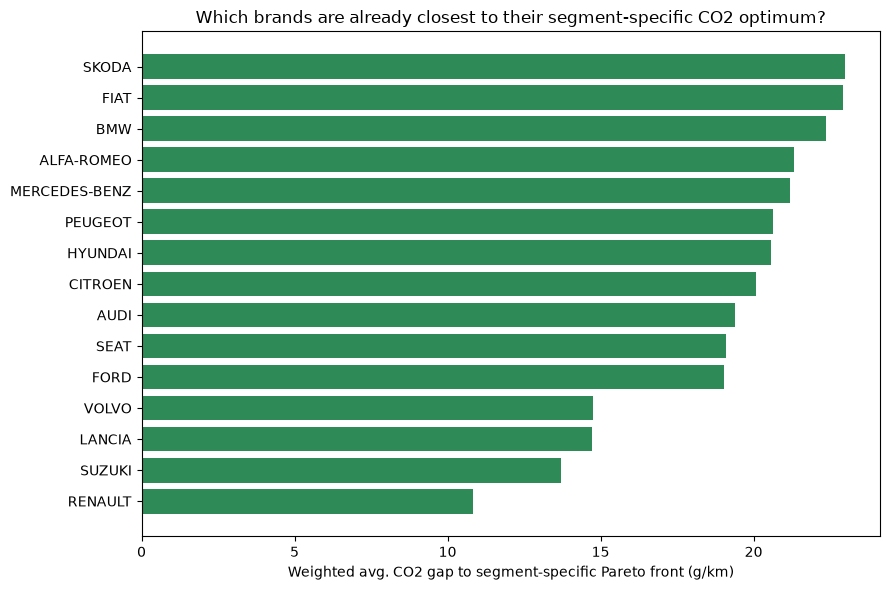

In [18]:
plot_brand_gap(brand_summary.sort_values('avg_co2_gap').head(15),
               'Which brands are already closest to their segment-specific CO2 optimum?', color='seagreen')

**How to read the chart above:** the mirror image – the brands with the *smallest* weighted gap. They show what "good" looks like within a segment and are a benchmark for the brands with more headroom.

## Step 12 – Residuals (where does the model go wrong?)

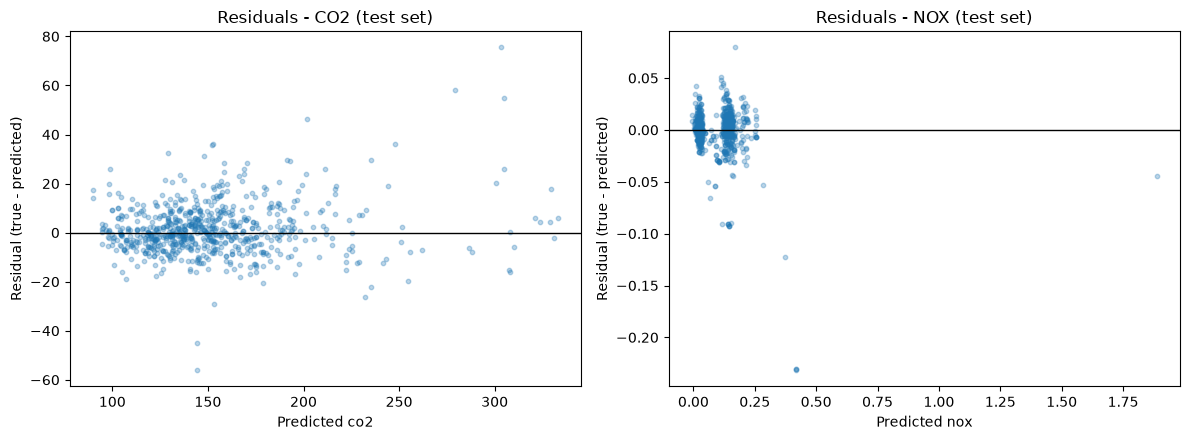


=== Average error per fuel type (test set) ===
Positive = model predicts too low on average, negative = too high.
Check the 'count' column before drawing conclusions from small groups.
                 count  mean_error_co2  mean_error_nox
fuel_grp                                              
Diesel             423           1.054          -0.002
Petrol             286           1.728           0.001
Electric/Hybrid     10          -3.459          -0.004
Gas(-Mix)            8          -2.457          -0.007

=== Average error per segment (test set) ===
Same reading as above: positive = model predicts too low, negative = too high.
Watch particularly for segments used heavily in Step 11b/11c/the taxation
bridge - a systematic bias here would directly bias those conclusions.
              count  mean_error_co2  mean_error_nox
segment_grp                                        
Lower-Medium    194           0.879          -0.001
Low/Economy     157           0.667           0.000
Luxury

In [19]:
residuals_df = X_test.copy()
for t in TARGETS:
    key = t.split('_')[0]                                  # 'co2' / 'nox'
    residuals_df[f'true_{key}'] = y_test[t].values
    residuals_df[f'predict_{key}'] = predict(t, X_test)
    residuals_df[f'residual_{key}'] = residuals_df[f'true_{key}'] - residuals_df[f'predict_{key}']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, key in zip(axes, ['co2', 'nox']):
    ax.scatter(residuals_df[f'predict_{key}'], residuals_df[f'residual_{key}'], alpha=0.3, s=10)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'Residuals - {key.upper()} (test set)')
    ax.set_xlabel(f'Predicted {key}')
    ax.set_ylabel('Residual (true - predicted)')
plt.tight_layout()
plt.show()

def error_table(column):
    return (residuals_df.groupby(column)
            .agg(count=('residual_co2', 'size'), mean_error_co2=('residual_co2', 'mean'), mean_error_nox=('residual_nox', 'mean'))
            .round(3).sort_values('count', ascending=False))

print('\n=== Average error per fuel type (test set) ===')
print('Positive = model predicts too low on average, negative = too high.')
print("Check the 'count' column before drawing conclusions from small groups.")
print(error_table('fuel_grp'))

print('\n=== Average error per segment (test set) ===')
print('Same reading as above: positive = model predicts too low, negative = too high.')
print('Watch particularly for segments used heavily in Step 11b/11c/the taxation')
print('bridge - a systematic bias here would directly bias those conclusions.')
print(error_table('segment_grp'))

## Step 13 – Save the models

In [20]:
print()
for t in TARGETS:
    file_name = f"best_model_{t.split('_')[0]}.joblib"
    joblib.dump(best_model[t], file_name)
    print(f"{TARGET_LABEL[t]} model ({best_name[t]}) saved to: {file_name}")

joblib.dump({'features': FEATURES, 'targets': TARGETS,
             'model_used_for_co2': best_name['co2_g_km'], 'model_used_for_nox': best_name['nox_g_km'],
             'weighted_by': 'r_merged (real-world registration numbers)'}, 'model_info.joblib')
print('Column info and chosen models saved to: model_info.joblib')


CO2 model (XGBoost) saved to: best_model_co2.joblib
NOx model (XGBoost) saved to: best_model_nox.joblib
Column info and chosen models saved to: model_info.joblib
